# FrequencyBasedSubstructuring — FBS-HBM Implementation
**Changes since commit `d2041da --> cdc8bfe`** — 18.05.2026

---

| File | Changes |
|---|---|
| `src/pyhbm/dynamical_system.py` | New `FBS_System` base class |
| `src/pyhbm/frequency_domain.py` | `FrequencyDomainFRF` simplified; new `FrequencyBasedSubstructuring` hierarchy |
| `src/pyhbm/__init__.py` | New exports: `FBS_System`, `FrequencyBasedSubstructuring_*`, `plot_FRF`, `save_solution_set` |
| `examples/FBS_test_linear/` | Completely rewritten — actual linear 8-DOF FBS test |
| `examples/duffing_FBS_2DoF/` | New example — nonlinear 2-DOF Duffing FBS |

---
## 1 · New `FBS_System` Base Class (`dynamical_system.py`)

`FBS_System` is a new base class for Frequency Based Substructuring problems.
It is **not** a subclass of `SecondOrderODE` — it carries block-diagonal system matrices for all substructures,
a signed Boolean coupling matrix $\mathbf{B}$, and defines the **interface force** instead of a global nonlinear force.

### 1.1 Attributes

| Attribute | Shape | Description |
|---|---|---|
| `mass_matrix` | $(d_{total} \times d_{total})$ | Block-diagonal mass matrix of all substructures |
| `damping_matrix` | $(d_{total} \times d_{total})$ | Block-diagonal damping matrix |
| `stiffness_matrix` | $(d_{total} \times d_{total})$ | Block-diagonal stiffness matrix |
| `B_coupling` | $(n_{int} \times d_{total})$ | Signed Boolean coupling matrix |
| `dimension` | int | $n_{int}$ — number of interface DOFs (= HBM unknowns per harmonic) |
| `polynomial_degree` | int | Degree of nonlinearity (controls AFT sampling) |

### 1.2 Semantic Interface (Subclasses Must Implement)

```python
def external_term(self, tau) -> np.ndarray:                       # (Nt, d_total, 1)
def interface_force(self, u_rel, u_rel_dot, tau) -> np.ndarray:   # (Nt, n_int, 1)
def jacobian_interface_force(self, u_rel, u_rel_dot, tau):        # (Nt, n_int, n_int)
def jacobian_interface_force_qdot(self, u_rel, u_rel_dot, tau):   # (Nt, n_int, n_int)
```

The key difference from `SecondOrderODE`: the nonlinear function now operates on
**relative interface displacements** $u_{rel} = \mathbf{B}\,u$ rather than on global DOFs.
The return value of `interface_force` is passed directly as $\mathbf{F}^{nl}$ inside `FrequencyBasedSubstructuring` — it is always treated as the **nonlinear coupling force**, even when the implementation happens to be linear (e.g. a validation test).

### 1.3 Framework Wrappers

`FrequencyBasedSubstructuring` calls the standard `SecondOrderODE`-style methods
(`nonlinear_term`, `jacobian_nonlinear_term`, `jacobian_nonlinear_term_qdot`).
On `FBS_System`, these are thin wrappers that delegate to the semantic interface:

```python
def nonlinear_term(self, u_rel, u_rel_dot, tau):
    return self.interface_force(u_rel, u_rel_dot, tau)

def jacobian_nonlinear_term(self, u_rel, u_rel_dot, tau):
    return self.jacobian_interface_force(u_rel, u_rel_dot, tau)

def jacobian_nonlinear_term_qdot(self, u_rel, u_rel_dot, tau):
    return self.jacobian_interface_force_qdot(u_rel, u_rel_dot, tau)
```

This allows `FrequencyBasedSubstructuring` to reuse the AFT machinery from
`FrequencyDomainSecondOrderODE_Real` without modification.

---
## 2 · New `FrequencyBasedSubstructuring` Class

### 2.1 Motivation & Physical Setup

In FBS, subsystems A and B are described by their individual FRF matrices $\mathbf{Y}^A(\omega)$, $\mathbf{Y}^B(\omega)$.
The combined **uncoupled** FRF is block-diagonal:

$$\mathbf{Y}^{A|B}(\omega) = \begin{bmatrix} \mathbf{Y}^A(\omega) & \mathbf{0} \\ \mathbf{0} & \mathbf{Y}^B(\omega) \end{bmatrix}$$

Subsystems are coupled through a **nonlinear coupling force** $\boldsymbol{\lambda}$ acting on the **relative interface displacement**:

$$u_{rel} = \mathbf{B}\,u, \qquad \mathbf{B} \in \mathbb{R}^{n_{int} \times d_{total}}$$

where $\mathbf{B}$ is the signed Boolean coupling matrix (each row selects an interface DOF pair with $+1/-1$ signs).

> **Convention:** $\boldsymbol{\lambda}$ (time domain) and $\boldsymbol{\Lambda}_n$ (Fourier coefficients of harmonic $n$) always denote the **nonlinear coupling force** $\mathbf{F}^{nl}$ throughout all FBS equations. It is the force transmitted between substructures at the coupling interface, depending on $u_{rel}$ (and optionally $\dot{u}_{rel}$).

### 2.2 FBS Residual — Derivation

The EOM of the uncoupled substructures under the nonlinear coupling force, per harmonic $n$:

$$\mathbf{Z}_n(\omega)\,\mathbf{Q}_n = \mathbf{F}^{ext}_n - \mathbf{B}^T\boldsymbol{\Lambda}_n
\quad\Rightarrow\quad
\mathbf{Q}_n = \mathbf{Y}_n(\omega)\left(\mathbf{F}^{ext}_n - \mathbf{B}^T\boldsymbol{\Lambda}_n\right)$$

where $\boldsymbol{\Lambda}_n = \mathbf{F}^{nl}_n$ are the Fourier coefficients of the **nonlinear coupling force** $\boldsymbol{\lambda}$ at harmonic $n$ (see §2.1 convention), and $\mathbf{B}^T$ distributes it onto the global DOFs with the correct signs.

The HBM unknowns are the Fourier coefficients of the **relative interface displacement**
$Q_{rel} = \mathbf{B}\,Q_{full}$. Multiplying from the left by $\mathbf{B}$ and rearranging:

$$\boxed{\mathbf{R} = \mathbf{Q}_{rel} - \mathbf{B}\,\mathbf{Y}^{A|B}\,\mathbf{F}^{ext} + \mathbf{B}\,\mathbf{Y}^{A|B}\,\mathbf{B}^T\,\mathbf{F}^{nl}(\mathbf{Q}_{rel}) = \mathbf{0}}$$

### 2.2 (cont.) — Implementation

```python
def compute_residue_RI(self, x: FourierOmegaPoint) -> array:
    state = x.fourier
    nonlin = self.compute_nonlinear_term(x)
    Q_rel  = vstack(state.coefficients)          # (Nh*n_int, 1)
    Fnl    = vstack(nonlin.coefficients)         # (Nh*n_int, 1)
    BY     = self.get_BY(x)                      # B @ Y, cached on x
    R      = Q_rel - BY @ self.F_ext_full + BY @ self.B_fourier.T @ Fnl
    return vstack((R.real, R.imag))
```

`self.B_fourier`, `self.B_RI`, `self.F_ext_full`, `self.F_ext_full_RI` are pre-computed once in `__init__`.
`get_BY(x)` and `get_BYBT_RI(x)` are cached on `x` per Newton step (see § 2.6).

### 2.3 FBS Jacobian

Differentiating the residual w.r.t. $\mathbf{Q}_{rel}$ (with $\mathbf{Y}$ and $\mathbf{F}^{ext}$ independent of $\mathbf{Q}_{rel}$):

$$\frac{\partial \mathbf{R}}{\partial \mathbf{Q}_{rel}} = \mathbf{I} + \mathbf{B}\,\mathbf{Y}^{A|B}\,\mathbf{B}^T\,\frac{\partial \mathbf{F}^{nl}}{\partial \mathbf{Q}_{rel}}$$

In RI block form, using $\mathbf{Y}_{RI} = \begin{bmatrix} \mathrm{Re}(\mathbf{Y}) & -\mathrm{Im}(\mathbf{Y}) \\ \mathrm{Im}(\mathbf{Y}) & \mathrm{Re}(\mathbf{Y}) \end{bmatrix}$:

$$\boxed{\mathbf{J}_{RI} = \mathbf{I} + \left(\mathbf{B}\,\mathbf{Y}^{A|B}\,\mathbf{B}^T\right)_{RI}\,\mathbf{J}^{nl}_{RI}}$$

```python
def compute_jacobian_of_residue_RI(self, x):
    Jnl    = self.compute_jacobian_nonlinear_term(x)
    Jnl_RI = block([[Jnl.RR, Jnl.RI], [Jnl.IR, Jnl.II]])
    return eye(self.real_dimension) + self.get_BYBT_RI(x) @ Jnl_RI
```

Compared to `FrequencyDomainFRF`: the FRF is projected by $\mathbf{B}(\cdot)\mathbf{B}^T$ before conversion to RI form.

### 2.4 Derivative w.r.t. $\omega$

Differentiating at fixed $\mathbf{Q}_{rel}$:

$$\frac{\partial \mathbf{R}}{\partial \omega}\Bigg|_{\mathbf{Q}_{rel}} =
\underbrace{\mathbf{B}\,\frac{d\mathbf{Y}}{d\omega}\left(\mathbf{B}^T\mathbf{F}^{nl} - \mathbf{F}^{ext}\right)}_{\text{FRF changes with }\omega}
+ \underbrace{\mathbf{B}\,\mathbf{Y}\,\mathbf{B}^T\,\frac{\partial \mathbf{F}^{nl}}{\partial \omega}\Bigg|_{\mathbf{Q}_{rel}}}_{\text{velocity-dependent nonlinearity}}$$

The velocity term arises from $\dot{u}_{rel} = \omega\,u'_{rel}$, giving
$\frac{\partial F^{nl}}{\partial\omega}\big|_{Q} = \dot{G}\,q'_{rel}$ (inherited from `FrequencyDomainSecondOrderODE_Real`).

### 2.4 (cont.) — Implementation

```python
def compute_derivative_wrt_omega_RI(self, x):
    state   = x.fourier
    dY_RI   = self.compute_FRF_derivative_wrt_omega_RI(x)
    Fnl     = Fourier.coefficients_to_RI(self.compute_nonlinear_term(x).coefficients)
    qdot_adim = state.get_adimensional_time_derivative()
    Gdot    = self.compute_Gdot(x)
    qdot_R  = vstack(qdot_adim.real)
    qdot_I  = vstack(qdot_adim.imag)
    derivative_nonlinear_RI = vstack((Gdot.RR @ qdot_R + Gdot.RI @ qdot_I,
                                      Gdot.IR @ qdot_R + Gdot.II @ qdot_I))
    BdY = self.B_RI @ dY_RI
    return (BdY @ self.B_RI.T @ Fnl
          + self.get_BYBT_RI(x) @ derivative_nonlinear_RI
          - BdY @ self.F_ext_full_RI)
```

### 2.5 Post-Processing: `compute_full_response`

Once continuation converges for $\mathbf{Q}_{rel}$, the full DOF response is reconstructed as:

$$\mathbf{Q}_{full} = \mathbf{Y}^{A|B}(\omega)\left(\mathbf{F}^{ext} - \mathbf{B}^T\,\mathbf{F}^{nl}(\mathbf{Q}_{rel})\right)$$

This maps the $n_{int}$-dimensional HBM solution back to all $d_{total}$ DOFs.

```python
def compute_full_response(self, fourier: Fourier, omega: float) -> Fourier:
    x    = FourierOmegaPoint(fourier, omega)
    Fnl  = vstack(self.compute_nonlinear_term(x).coefficients)    # (Nh*n_int, 1)
    Y    = self.get_FRF(x)                                         # (Nh*d_total, Nh*d_total)
    Q_full = Y @ (self.F_ext_full - self.B_fourier.T @ Fnl)       # (Nh*d_total, 1)
    return Fourier(Q_full.reshape(Nh, d_total, 1))
```

### 2.6 Cache Methods: `get_BY` and `get_BYBT_RI`

Within each Newton step, `compute_residue_RI` and `compute_jacobian_of_residue_RI` are both called on the same `x`. At the end of each continuation step, `compute_derivative_wrt_omega_RI` is called on the same last `x`. Three intermediate matrices would otherwise be recomputed redundantly:

| Matrix | Used by | Cached as |
|---|---|---|
| $\mathbf{Y}^{A\|B}(\omega)$ | residue, Jacobian, dR/dω | `x.Y_frf_cache` (inherited from `FrequencyDomainFRF`) |
| $\mathbf{B}\,\mathbf{Y}^{A\|B}$ | residue, Jacobian | `x.BY_cache` |
| $\left(\mathbf{B}\,\mathbf{Y}^{A\|B}\,\mathbf{B}^T\right)_{RI}$ | Jacobian, dR/dω | `x.BYBT_RI_cache` |

Two new cache slots are added to `FourierOmegaPoint.__init__`:

```python
self.BY_cache      = None   # B_fourier @ Y  (complex)
self.BYBT_RI_cache = None   # FRF_to_RI(B @ Y @ B.T)  (real)
```

The cache methods follow the same pattern as `get_FRF`. `get_BYBT_RI` calls `get_BY` internally, so `B @ Y` is never computed more than once per `x`:

```python
def get_BY(self, x: FourierOmegaPoint) -> array:
    if x.BY_cache is None:
        x.BY_cache = self.B_fourier @ self.get_FRF(x)
    return x.BY_cache

def get_BYBT_RI(self, x: FourierOmegaPoint) -> array:
    if x.BYBT_RI_cache is None:
        x.BYBT_RI_cache = self.FRF_to_RI(self.get_BY(x) @ self.B_fourier.T)
    return x.BYBT_RI_cache
```

Additionally, `self.F_ext_full_RI = Fourier.coefficients_to_RI(self.F_ext_full)` is pre-computed once in `__init__` since `F_ext_full` is a constant — replacing a repeated call inside `compute_derivative_wrt_omega_RI`.

### 2.7 Concrete Subclasses

`FrequencyBasedSubstructuring` is abstract — `compute_FRF` and `compute_FRF_derivative_wrt_omega_RI` are left as `pass`.
Two concrete subclasses mirror the `FrequencyDomainFRF_*` pattern:

| Class | FRF source | $d\mathbf{Y}/d\omega$ |
|---|---|---|
| `FrequencyBasedSubstructuring_numerical` | Solved from $\mathbf{M, C, K}$ per harmonic | Analytical: $-\mathbf{Y}_n\frac{d\mathbf{Z}_n}{d\omega}\mathbf{Y}_n$ |
| `FrequencyBasedSubstructuring_experimental` | Cubic spline interpolation of stored data | Central finite differences |

**Numerical subclass** — FRF and its derivative computed from system matrices:

$$\mathbf{Y}_n(\omega) = \mathbf{Z}_n(\omega)^{-1}, \quad \mathbf{Z}_n = -n^2\omega^2\mathbf{M} + jn\omega\mathbf{C} + \mathbf{K}$$

$$\frac{d\mathbf{Y}_n}{d\omega} = -\mathbf{Y}_n\,\frac{d\mathbf{Z}_n}{d\omega}\,\mathbf{Y}_n, \quad \frac{d\mathbf{Z}_n}{d\omega} = -2n^2\omega\,\mathbf{M} + jn\,\mathbf{C}$$

**Experimental subclass** — the `FBS_System` subclass must provide `self.omega_frf` (shape $(N_{freq},)$) and `self.Y_frf` (shape $(N_{freq}, d_{total}, d_{total})$). Identical interpolation strategy to `FrequencyDomainFRF_experimental`: cubic splines on real and imaginary parts separately, with conjugate symmetry $\mathbf{Y}(-\omega) = \overline{\mathbf{Y}(\omega)}$.

### 2.8 Inheritance Diagram

```
FrequencyDomainSecondOrderODE
    └── FrequencyDomainSecondOrderODE_Real    (AFT, Gdot, kron matrices)
            └── FrequencyDomainFRF            (FRF residual & Jacobian)
                    ├── FrequencyDomainFRF_experimental
                    ├── FrequencyDomainFRF_numerical
                    └── FrequencyBasedSubstructuring        ← NEW (abstract)
                            ├── FrequencyBasedSubstructuring_numerical
                            └── FrequencyBasedSubstructuring_experimental
```

`FrequencyBasedSubstructuring` overrides three methods from `FrequencyDomainFRF`:

| Method | `FrequencyDomainFRF` | `FrequencyBasedSubstructuring` |
|---|---|---|
| `compute_residue_RI` | $\mathbf{Q} + \mathbf{Y}\mathbf{F}^{nl} - \mathbf{Y}\mathbf{F}^{ext}$ | $\mathbf{Q}_{rel} - \mathbf{B}\mathbf{Y}\mathbf{F}^{ext} + \mathbf{B}\mathbf{Y}\mathbf{B}^T\mathbf{F}^{nl}$ |
| `compute_jacobian_of_residue_RI` | $\mathbf{I} + \mathbf{Y}_{RI}\mathbf{J}^{nl}_{RI}$ | $\mathbf{I} + (\mathbf{B}\mathbf{Y}\mathbf{B}^T)_{RI}\mathbf{J}^{nl}_{RI}$ |
| `compute_derivative_wrt_omega_RI` | $\frac{d\mathbf{Y}}{d\omega}(\mathbf{F}^{nl}-\mathbf{F}^{ext}) + \mathbf{Y}\dot{G}q'$ | same, but all terms projected by $\mathbf{B}_{RI}(\cdot)\mathbf{B}^T_{RI}$ |

`compute_nonlinear_term`, `compute_jacobian_nonlinear_term`, `compute_Gdot` are **inherited unchanged**.

---
## 3 · `__init__.py` — New Exports

```python
# dynamical_system.py
from .dynamical_system import (
    FirstOrderODE,
    SecondOrderODE,         # <- new
    FBS_System,             # <- new
)

# frequency_domain.py
from .frequency_domain import (
    ...
    FrequencyBasedSubstructuring,              # <- new
    FrequencyBasedSubstructuring_numerical,    # <- new
    FrequencyBasedSubstructuring_experimental, # <- new
)

# utility functions (previously only accessible as methods on SolutionSet)
"plot_FRF",           # <- new standalone function
"save_solution_set",  # <- new standalone function
```

---
## 4 · Example: `FBS_test_linear` — Linear 8-DOF System

The example was **completely rewritten**. Previously it contained a single-subsystem 4-DOF Duffing placeholder (`DuffingForced_SecondOrder`) that did not implement any actual FBS logic. It now tests the full FBS pipeline on a proper two-subsystem linear system.

### 4.1 System Diagram

Two identical 4-DOF chain subsystems A and B, coupled at 3 interface DOF pairs by a **linear** interface force.

```
  P*cos(tau)
       |
     [A0]--k,d--[A1]--k,d--[A2]--k,d--[A3]
                  |  L1       |  L2       |  L3
             [B0]--k,d--[B1]--k,d--[B2]--k,d--[B3]

  Li = linear interface coupling force
  u_rel,1 = u_A1 - u_B0
  u_rel,2 = u_A2 - u_B1
  u_rel,3 = u_A3 - u_B2
```

DOF layout (columns of $\mathbf{B}$): $[u_{A_0}, u_{A_1}, u_{A_2}, u_{A_3}, u_{B_0}, u_{B_1}, u_{B_2}, u_{B_3}]$

Note: the chains are **free-free** (no grounding springs). Only the interface coupling holds the structure together.

### 4.2 Equations of Motion — Subsystems (A and B identical)

$$\mathbf{M}\ddot{u}^s + \mathbf{D}\dot{u}^s + \mathbf{K}\,u^s = f^{ext,s} + \mathbf{B}_s^T\,\boldsymbol{\lambda}, \quad s \in \{A, B\}$$

$$\mathbf{M} = \mathbf{I}_4, \qquad
\mathbf{D} = \begin{bmatrix} d & -d & & \\ -d & 2d & -d & \\ & -d & 2d & -d \\ & & -d & d \end{bmatrix}, \qquad
\mathbf{K} = \begin{bmatrix} k & -k & & \\ -k & 2k & -k & \\ & -k & 2k & -k \\ & & -k & k \end{bmatrix}$$

External force: $f^{ext,A}_0 = P\cos(\tau)$, all other entries zero.

### 4.3 Equations of Motion — Interface

The interface force is **linear** in relative displacement and velocity:

$$\boldsymbol{\lambda}(u_{rel},\,\dot{u}_{rel}) = k\,u_{rel} + d\,\dot{u}_{rel}, \qquad u_{rel} \in \mathbb{R}^3$$

The coupling matrix $\mathbf{B} \in \mathbb{R}^{3 \times 8}$:

$$\mathbf{B} = \begin{bmatrix}
0 & 1 & 0 & 0 & -1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & -1 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & -1 & 0
\end{bmatrix}$$

**Note:** because the interface force equals the linear stiffness/damping of the coupling, this is a
**linear** FBS problem — the FRF-based residual reduces to a linear system and the Newton solver converges in one step.

### 4.4 Reference System — Fully Assembled 8-DOF

The reference (`linearFBS_System_Reference`, a `SecondOrderODE`) assembles the **coupled** system directly.
The coupling term $k\,\mathbf{B}^T\mathbf{B}$ adds the interface stiffness into the diagonal blocks and introduces off-diagonal cross-coupling between A and B:

$$\mathbf{M}_{full}\,\ddot{u} + \mathbf{D}_{full}\,\dot{u} + \mathbf{K}_{full}\,u = f^{ext},
\qquad u = [u_{A_0},\, u_{A_1},\, u_{A_2},\, u_{A_3},\, u_{B_0},\, u_{B_1},\, u_{B_2},\, u_{B_3}]^T$$

$$\mathbf{K}_{full} = \begin{bmatrix}
 k & -k &  0 &  0 &  0 &  0 &  0 &  0 \\
-k & 3k & -k &  0 & -k &  0 &  0 &  0 \\
 0 & -k & 3k & -k &  0 & -k &  0 &  0 \\
 0 &  0 & -k & 2k &  0 &  0 & -k &  0 \\
 0 & -k &  0 &  0 & 2k & -k &  0 &  0 \\
 0 &  0 & -k &  0 & -k & 3k & -k &  0 \\
 0 &  0 &  0 & -k &  0 & -k & 3k & -k \\
 0 &  0 &  0 &  0 &  0 &  0 & -k &  k
\end{bmatrix}, \qquad
\mathbf{D}_{full} = \begin{bmatrix}
 d & -d &  0 &  0 &  0 &  0 &  0 &  0 \\
-d & 3d & -d &  0 & -d &  0 &  0 &  0 \\
 0 & -d & 3d & -d &  0 & -d &  0 &  0 \\
 0 &  0 & -d & 2d &  0 &  0 & -d &  0 \\
 0 & -d &  0 &  0 & 2d & -d &  0 &  0 \\
 0 &  0 & -d &  0 & -d & 3d & -d &  0 \\
 0 &  0 &  0 & -d &  0 & -d & 3d & -d \\
 0 &  0 &  0 &  0 &  0 &  0 & -d &  d
\end{bmatrix}$$

The pattern is clear: A-chain and B-chain each contribute their tridiagonal neighbor-coupling; the three interface pairs $(A_1,B_0)$, $(A_2,B_1)$, $(A_3,B_2)$ add $k$ (resp. $d$) to the diagonal of the coupled DOF and $-k$ (resp. $-d$) to the off-diagonal cross-terms.

There is no nonlinear term — the reference is a **linear** 8-DOF system and validates the FBS formulation: FBS numerical, FBS experimental, and the reference must all produce the same frequency response.

### 4.5 Results

#### Test Case 1 — High Damping &nbsp;&nbsp; $d = 0.9,\; k = 1.0,\; P = 1.0$

<p><figure style="text-align: center;">
<img src="./FBS_test_linear_d, k, P = 0.9, 1.0, 1.0.png" width="1200"/>
</figure></p>
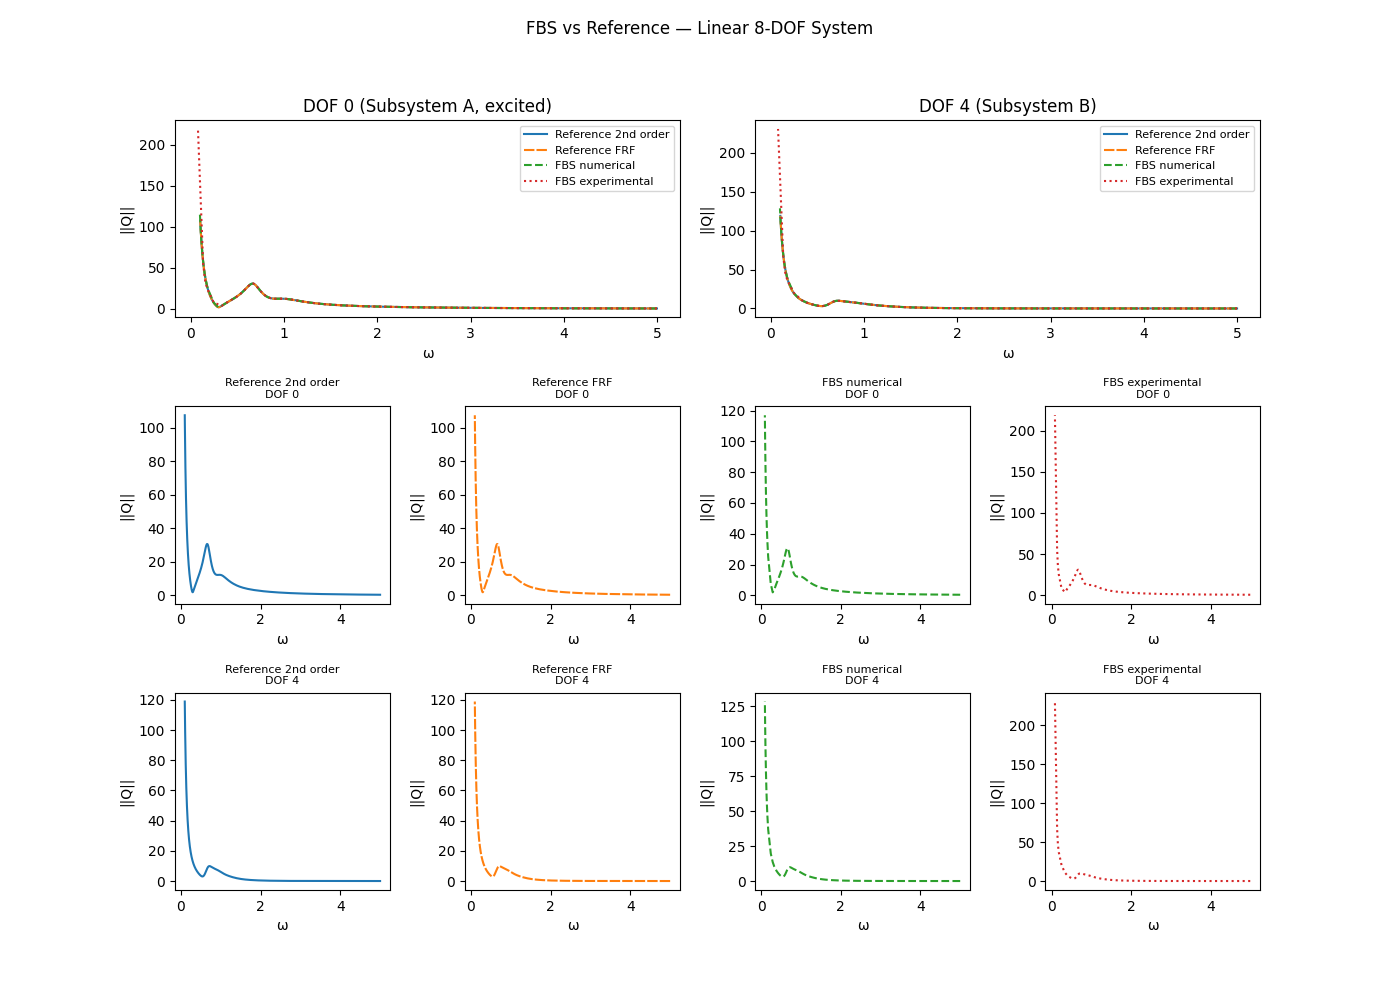

#### Test Case 2 — Low Damping &nbsp;&nbsp; $d = 0.09,\; k = 1.0,\; P = 1.0$

<p><figure style="text-align: center;">
<img src="./FBS_test_linear_d, k, P = 0.09, 1.0, 1.0.png" width="1200"/>
</figure></p>

---
## 5 · New Example: `duffing_FBS_2DoF` — Nonlinear 2-DOF Duffing FBS

This is the first **nonlinear** FBS validation example. Two single-DOF oscillators, each grounded by their own spring, coupled through a nonlinear interface force. The reference solution uses the standard 1st-order HBM on the full state-space system.

### 5.1 System Diagram

```
  P*cos(tau)
       |
  ///--[m1]--k1,c1--///      (Subsystem A, 1 DOF)
       |
   lambda(u_rel)  =  k3*u_rel + beta*u_rel^3 + alpha*u_rel^2*u_rel_dot    <- nonlinear coupling force
       |
  ///--[m2]--k2,c2--///      (Subsystem B, 1 DOF)

  u_rel = u1 - u2,    B = [1, -1]    =>  n_int = 1  (scalar problem)
```

### 5.2 Equations of Motion — Uncoupled Subsystems

$$m_1\ddot{u}_1 + c_1\dot{u}_1 + k_1 u_1 = P\cos(\tau) - \lambda, \qquad
m_2\ddot{u}_2 + c_2\dot{u}_2 + k_2 u_2 = +\lambda$$

The sign convention follows $\mathbf{B}^T\lambda = [1,\,-1]^T\lambda$: the nonlinear coupling force acts as a
restoring force on mass 1 and an equal-but-opposite force on mass 2.

### 5.3 Equations of Motion — Nonlinear Coupling Force

$$\lambda(u_{rel},\,\dot{u}_{rel}) = k_3\,u_{rel} + \beta\,u_{rel}^3 + \alpha\,u_{rel}^2\,\dot{u}_{rel}$$

The three terms represent:
- $k_3\,u_{rel}$ — linear coupling stiffness
- $\beta\,u_{rel}^3$ — cubic (Duffing-type) nonlinear spring
- $\alpha\,u_{rel}^2\,\dot{u}_{rel}$ — amplitude-dependent nonlinear damping

The FBS residual with $\mathbf{B} = [1,\,-1]$ (scalar, one unknown per harmonic):

$$R = Q_{rel} - \mathbf{B}\,\mathbf{Y}^{A|B}(\omega)\,F^{ext} + \mathbf{B}\,\mathbf{Y}^{A|B}(\omega)\,\mathbf{B}^T\,\lambda(Q_{rel}) = 0$$

For the reference, the full 2-DOF system in state space is used ($z = [u_1,\dot{u}_1,u_2,\dot{u}_2]^T$, `System2DoF_1stOrder`).

### 5.4 Test Case 1 — Nonlinear Spring

| Parameter | Value | Description |
|---|---|---|
| $c_1 = c_2$ | $0.09$ | Linear viscous damping per subsystem |
| $k_1 = k_2$ | $1.0$ | Linear grounding stiffness ($\omega_{res} = 1\,\text{rad/s}$) |
| $k_3$ | $0.0$ | No linear coupling stiffness |
| $\beta$ | $1.0$ | Cubic nonlinear spring: $\lambda = \beta\,u_{rel}^3$ |
| $\alpha$ | $0.0$ | No nonlinear damping |
| $P$ | $1.0$ | External force amplitude |
| Harmonics | $[1,3,5,7,9]$ | HBM truncation order |
| $\omega \in$ | $[0.0,\, 5.0]$ | Frequency sweep range (rad/s) |

The coupling reduces to a pure Duffing spring $\lambda = u_{rel}^3$. Two resonance peaks appear (symmetric and anti-symmetric modes of the coupled system), both bent to the right by the hardening nonlinearity. All three solvers — Reference 1st order, FBS numerical, FBS experimental — must overlap.

<p><figure style="text-align: center;">
<img src="./duffing_FBS_2DoF_(c1, c2, k1, k2, k3, beta, alpha, P = 0.09, 0.09, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0).png" width="1000"/>
</figure></p>

### 5.5 Test Case 2 — Nonlinear Damping

| Parameter | Value | Description |
|---|---|---|
| $c_1 = c_2$ | $0.09$ | Linear viscous damping per subsystem |
| $k_1 = k_2$ | $1.0$ | Linear grounding stiffness ($\omega_{res} = 1\,\text{rad/s}$) |
| $k_3$ | $0.0$ | No linear coupling stiffness |
| $\beta$ | $0.0$ | No nonlinear spring |
| $\alpha$ | $0.9$ | Amplitude-dependent nonlinear damping: $\lambda = \alpha\,u_{rel}^2\,\dot{u}_{rel}$ |
| $P$ | $1.0$ | External force amplitude |
| Harmonics | $[1,3,5,7,9]$ | HBM truncation order |
| $\omega \in$ | $[0.0,\, 5.0]$ | Frequency sweep range (rad/s) |

The coupling reduces to a pure nonlinear damper $\lambda = \alpha\,u_{rel}^2\,\dot{u}_{rel}$. The resonance peaks remain at the linear natural frequencies (no stiffness nonlinearity) but are amplitude-dependent in damping — peaks are suppressed and broadened at high amplitude. This case tests the velocity-dependent nonlinear term in the Jacobian ($\alpha \neq 0$ activates the `jacobian_interface_force_qdot` path).

<p><figure style="text-align: center;">
<img src="./duffing_FBS_2DoF_(c1, c2, k1, k2, k3, beta, alpha, P = 0.09, 0.09, 1.0, 1.0, 0.0, 0.0, 0.9, 1.0).png" width="1000"/>
</figure></p>